# KNF - nearest neighcors

Tshirt.csv

In [ ]:
# Euclidear Distance =      /--------------------------
#                        \/ (f11-f12)^2 + (f21-f22)^2 

# TP --> True Positive
# TN --> True Negative
# FP --> False Positive
# FN --> False Negative


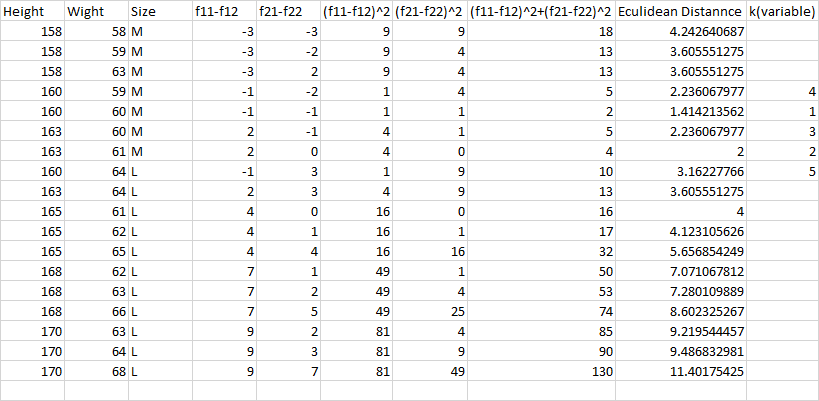

In [1]:
import pandas as pd

df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
x=df.iloc[:,0:8]
y=df["Outcome"]
print(x)
print(x.shape)
print(y)
print(y.shape)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [5]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [7]:
from sklearn.neighbors import KNeighborsClassifier

nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [10]:
from sklearn.neighbors import KNeighborsClassifier

model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)
print(prediction.size)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]
154


In [11]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":prediction})
diff

,Actual,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [13]:
diff.to_excel("diabetes_data.xlsx")  # to download excel file

In [ ]:
# A P 
# 0 0 -->  89  TN
# 0 1 -->  10  FP
# 1 0 -->  23  FN
# 1 1 -->  32  TP
#         ----
#         154

In [15]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


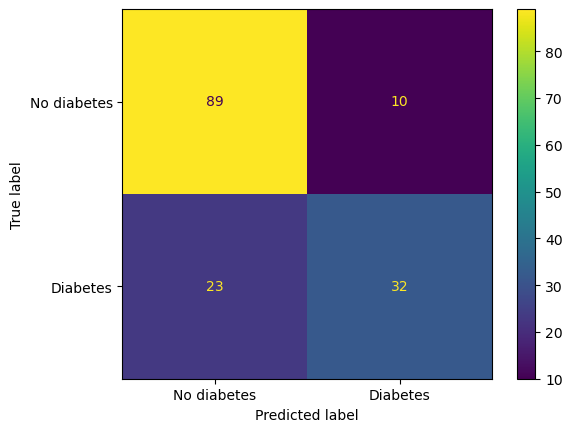

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No diabetes","Diabetes"])
cm_display.plot()
plt.show()

In [17]:
cm

array([[89, 10],
       [23, 32]])

In [19]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

print("TN:",TN," FP:",FP," FN:",FN," TP:",TP)

TN: 89  FP: 10  FN: 23  TP: 32


In [23]:
# Accuracy = percentage of True prediction (TN+TP)/(TN+FP+FN+TP)

Accuracy=(TN+TP)/154
print("Accuracy Score :",Accuracy)

Accuracy Score : 0.7857142857142857


In [24]:
from sklearn.metrics import accuracy_score
print("Accuracy Score :",accuracy_score(y_test,prediction))

Accuracy Score : 0.7857142857142857


In [26]:
# Error_rate = percentage of True prediction (FN+FP)/(TN+FP+FN+TP)

Error_rate=(FN+FP)/154
print("Error_rate :",Error_rate)

Error_rate : 0.21428571428571427


In [28]:
from sklearn.metrics import accuracy_score
print("Error_rate :",1-accuracy_score(y_test,prediction))

Error_rate : 0.2142857142857143


In [32]:
# Sensitivity = percentage of positive cases are classify correctly (TP)/(TP+FN)

Sensitivity=(TP)/(TP+FN)
print("Sensitivity :",Sensitivity)

Sensitivity : 0.5818181818181818


In [34]:
# Specificity = percentage of Nagetive cases are classify correctly (TN)/(TN+FP)

Specificity=(TN)/(TN+FP)
print("Specificity :",Specificity)

Specificity : 0.898989898989899


In [36]:
from sklearn.metrics import recall_score

print("Sensitivity :",recall_score(y_test,prediction,pos_label=1)) # pos_label=1 is by defult
print("Specificity :",recall_score(y_test,prediction,pos_label=0))

Sensitivity : 0.5818181818181818
Specificity : 0.898989898989899


In [37]:
# Precision Score = for positive (TP)/(TP+FP)

Precision_Score=(TP)/(TP+FP)
print("Precision Score :",Precision_Score)

Precision Score : 0.7619047619047619


In [41]:
# Precision Score = for nagetive (TN)/(TN+FN)

Precision_Score=(TN)/(TN+FN)
print("Precision Score :",Precision_Score)

Precision Score : 0.7946428571428571


In [40]:
from sklearn.metrics import precision_score

print("Precision Score (for positive):",precision_score(y_test,prediction,pos_label=1)) # pos_label=1 is by defult
print("Precision Score (for nagetive):",precision_score(y_test,prediction,pos_label=0))

Precision Score (for positive): 0.7619047619047619
Precision Score (for nagetive): 0.7946428571428571


# maximum accuracy in first 30 data

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
accuracy=[]
for i in range(1,31):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    prediction=model.predict(x_test)
    accuracy.append(accuracy_score(y_test,prediction))
print(accuracy)
print("-"*15)
print("Max:",max(accuracy))

[0.7207792207792207, 0.7272727272727273, 0.7402597402597403, 0.7207792207792207, 0.7337662337662337, 0.7727272727272727, 0.7597402597402597, 0.7662337662337663, 0.7662337662337663, 0.7597402597402597, 0.7467532467532467, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7857142857142857, 0.7857142857142857, 0.7857142857142857, 0.7727272727272727, 0.7727272727272727, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7662337662337663, 0.7792207792207793, 0.7532467532467533, 0.7727272727272727, 0.7532467532467533, 0.7662337662337663, 0.7662337662337663, 0.7792207792207793]
---------------
Max: 0.7857142857142857


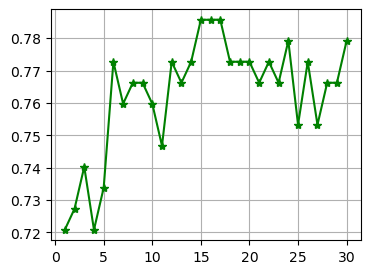

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(range(1,31),accuracy,marker="*",c="green")
plt.grid(True)
plt.show()

### ----------------------------------------------------------------------------------------------------------------

In [53]:
import pandas as pd

df=pd.read_csv("tshirt.csv")
df.head()

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M


In [54]:
x=df.iloc[:,0:2]
y=df["Size"]
print(x)
print(x.shape)
print(y)
print(y.shape)

    Height  Wight
0      158     58
1      158     59
2      158     63
3      160     59
4      160     60
5      163     60
6      163     61
7      160     64
8      163     64
9      165     61
10     165     62
11     165     65
12     168     62
13     168     63
14     168     66
15     170     63
16     170     64
17     170     68
(18, 2)
0     M
1     M
2     M
3     M
4     M
5     M
6     M
7     L
8     L
9     L
10    L
11    L
12    L
13    L
14    L
15    L
16    L
17    L
Name: Size, dtype: object
(18,)


In [55]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

['M' 'M' 'M' 'M' 'M' 'M' 'L' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']


In [56]:
diff=pd.DataFrame({"Actual":y,"Predicted":prediction})
diff

,Actual,Predicted
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
5,M,M
6,M,L
7,L,M
8,L,L
9,L,L


In [57]:
diff.to_excel("shirt_data.xlsx")  # to download excel file

In [58]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[10  1]
 [ 1  6]]


In [59]:
from sklearn.metrics import accuracy_score
print("Acuracy Score :",accuracy_score(y,prediction))
print("Error Rate :",1-accuracy_score(y,prediction))

Acuracy Score : 0.8888888888888888
Error Rate : 0.11111111111111116


In [60]:
from sklearn.metrics import recall_score
print("Sensitivity :",recall_score(y,prediction,pos_label="M"))
print("Specificity :",recall_score(y,prediction,pos_label="L")) 

Sensitivity : 0.8571428571428571
Specificity : 0.9090909090909091


In [61]:
from sklearn.metrics import precision_score
print("Precision Score(For Positive) :",precision_score(y,prediction,pos_label="M"))
print("Precision Score(For Negetive) :",precision_score(y,prediction,pos_label="L")) 

Precision Score(For Positive) : 0.8571428571428571
Precision Score(For Negetive) : 0.9090909090909091


### ----------------------------------------------------------------------------------------------------------------

In [63]:
import pandas as pd

df=pd.read_csv("AptitudeCommunication.csv")
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Speaker
8,Govind,8,3.0,Intel
9,Sushant,6,5.5,Leader


In [68]:
x=df.iloc[:,1:3]
y=df["Class"]
print(x)
print(x.shape)
print(y)
print(y.shape)

    Aptitude  Communication
0          2            5.0
1          2            6.0
2          7            6.0
3          7            2.5
4          8            6.0
5          4            7.0
6          5            3.0
7          3            5.5
8          8            3.0
9          6            5.5
10         6            4.0
11         6            7.0
12         6            2.0
13         9            7.0
(14, 2)
0     Speaker
1     Speaker
2      Leader
3       Intel
4      Leader
5     Speaker
6       Intel
7     Speaker
8       Intel
9      Leader
10      Intel
11     Leader
12      Intel
13     Leader
Name: Class, dtype: object
(14,)


In [73]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

['Speaker' 'Speaker' 'Leader' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Leader' 'Intel' 'Leader' 'Intel' 'Leader']


In [74]:
diff=pd.DataFrame({"Actual":y,"Predicted":prediction})
diff

,Actual,Predicted
0,Speaker,Speaker
1,Speaker,Speaker
2,Leader,Leader
3,Intel,Intel
4,Leader,Leader
5,Speaker,Speaker
6,Intel,Intel
7,Speaker,Speaker
8,Intel,Intel
9,Leader,Leader


In [75]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[5 0 0]
 [0 5 0]
 [0 0 4]]


In [72]:
from sklearn.metrics import accuracy_score
print("Acuracy Score :",accuracy_score(y,prediction))
print("Error Rate :",1-accuracy_score(y,prediction))

Acuracy Score : 1.0
Error Rate : 0.0


# Decision Tree

In [4]:
import pandas as pd

df=pd.read_csv("DecisionTree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


# Entropy(S) = -p(yes)log2(p(yes)) - p(no)log2(p(no))

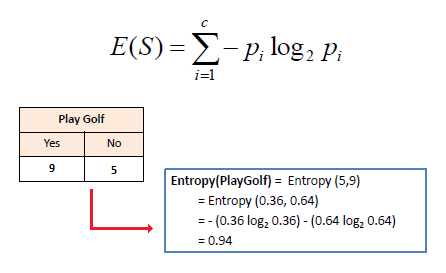

# IG of weather

##### Entropy of Sunny =  (-2/5) log2 (2/5) - (3/5) log2 (3/5)  = 0.97
#####  {+2 , -3 }

##### Entropy Of Rain =  (-3/5) log2 (3/5) - (2/5) log2 (2/5)  = 0.97
#####  {+3 , -2}

##### Entropy Of Cloudy = (-4/4) log2 (4/4) - (0/4) log2 (0/4) = 0
#####  {+4 , 0}

##### IG(Weather) = s(Whole Data) - ((5/14) s(Sunny)) + ((5/14) s(Rainy)) +((4/14) s(Cloudy))
#####             = 0.94 - ((5/14) (0.97)) + ((5/14) (0.97)) +((4/14) (0))
#####             = 0.247

# --------------------------------------------------------------------------------------

##### IG Of Tempreture
##### Entropy of Hot { +2 , -2} =  (-2/5) log2 (2/5) - (2/5) log2 (2/5)  = 1
##### Entropy of Mild { +4 , -2} =  (-4/6) log2 (4/6) - (2/6) log2 (2/6) = 0.91
##### Entropy of Cold { +3 , -1} =  (-3/4) log2 (3/4) - (1/4) log2 (1/4) = 0.81

##### IG(Tempreture) = s(Whole Data) - ((4/14) s(Hot)) + ((6/14) s(Mild)) +((4/14) s(Cold))
#####             = 0.94 - ((4/14) (1)) + ((6/14) (0.91)) +((4/14) (0.81))
#####             = 0.032

# --------------------------------------------------------------------------------------

##### IG Of Humidity

##### Entropy of High   { +3 , -4 } = (-3/7) log2 (3/7) - (4/7) log2 (4/7) = 0.98
##### Entropy of Normal { +6 , -1 } = (-6/7) log2 (6/7) - (1/7) log2 (1/7) = 0.59

##### IG(Humidity) = s(Whole Data) - ((7/14) s(High)) + ((7/14) s(Normal)) 
#####             = 0.94 - (((7/14) (0.98)) +((7/14) (0.59)))
#####             = 0.155

# --------------------------------------------------------------------------------------

##### IG Of Wind

##### Entropy of Strong   { +3 , -3 } = (-3/6) log2 (3/6) - (3/6) log2 (3/6) = 1
##### Entropy of Weak { +6 , -2 } = (-6/8) log2 (6/8) - (2/8) log2 (2/8) = 0.81

##### IG(Wind) = s(Whole Data) - ((7/14) s(Strong)) + ((7/14) s(Weak)) 
#####             = 0.94 - (((6/14) (1)) +((8/14) (0.81)))
#####             = 0.048

# --------------------------------------------------------------------------------------

##### S(Sunny) = 0.97
##### IG of Temprature for sunny
##### Hot { 0 , -2} = 0
##### Mild { +1 , -1} = 1
##### Cold { +1 , 0} = 0

##### IG of Humidity for sunny
##### High { 0 , -3} = 0
##### Normal { 2 , 0} = 0


# --------------------------------------------------------------------------------------

##### IG(Hum,s) = 0.97

##### IG(S,T) = 0.57
##### IG(S,H) = 0.97
##### IG(S,W) = 0.018

##### IG(Temp,s) = 0.97 - ((2/5)(0) + (2/5)(1) +(1/5)(0))
#####            = 0.57

# --------------------------------------------------------------------------------------

##### IG of Temprature for Rainy
##### Hot { 0 , 0} = 0
##### Mild { 2 , -1} = 0.918
##### Cold { +1 , -1} = 1

# --------------------------------------------------------------------------------------

##### IG(R,T) = 0.0192
##### IG(R,H) = 0.0192
##### IG(R,W) = 0.97

##### IG(Hum,R) = 0.97 - ((0) + (3/5)(0.918) +(2/5)(1))
#####           = 0.0192

In [7]:
import pandas as pd

df = pd.read_csv("DecisionTree_Sports.csv")


df = df.replace({
    'Cloudy': 0, 'Rain': 1, 'Sunny': 2,
    'Cool': 0, 'Hot': 1, 'Mild': 2,
    'High': 0, 'Normal': 1,
    'Strong': 0, 'Weak': 1,
    'No': 0 , 'Yes': 1
})

print(df)


       Day  Weather  Temperature  Humidity  Wind  Play_Sports?
0    Day 1        2            1         0     1             0
1    Day 2        2            1         0     0             0
2    Day 3        0            1         0     1             1
3    Day 4        1            2         0     1             1
4    Day 5        1            0         1     1             1
5    Day 6        1            0         1     0             0
6    Day 7        0            0         1     0             1
7    Day 8        2            2         0     1             0
8    Day 9        2            0         1     1             1
9   Day 10        1            2         1     1             1
10  Day 11        2            2         1     0             1
11  Day 12        0            2         0     0             1
12  Day 13        0            1         1     1             1
13  Day 14        1            2         0     0             0


C:\Users\LJENG\AppData\Local\Temp\ipykernel_10808\3138958248.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


In [13]:
df.to_excel("DecisionTree_Sports_modified.xlsx")  # to download excel file

In [8]:
x=df.iloc[:,1:5]
y=df["Play_Sports?"]
print(x)
print(x.shape)
print(y)
print(y.shape)

    Weather  Temperature  Humidity  Wind
0         2            1         0     1
1         2            1         0     0
2         0            1         0     1
3         1            2         0     1
4         1            0         1     1
5         1            0         1     0
6         0            0         1     0
7         2            2         0     1
8         2            0         1     1
9         1            2         1     1
10        2            2         1     0
11        0            2         0     0
12        0            1         1     1
13        1            2         0     0
(14, 4)
0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: Play_Sports?, dtype: int64
(14,)


In [9]:
from sklearn.tree import DecisionTreeClassifier

dtree= DecisionTreeClassifier(criterion="entropy")
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [10]:
dtree.get_depth()

4

In [11]:
from sklearn import tree

text_representation=tree.export_text(dtree,feature_names=["Weather","Temperature","Humidity","Wind"])
print(text_representation)

|--- Weather <= 0.50
|   |--- class: 1
|--- Weather >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Weather <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Weather >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



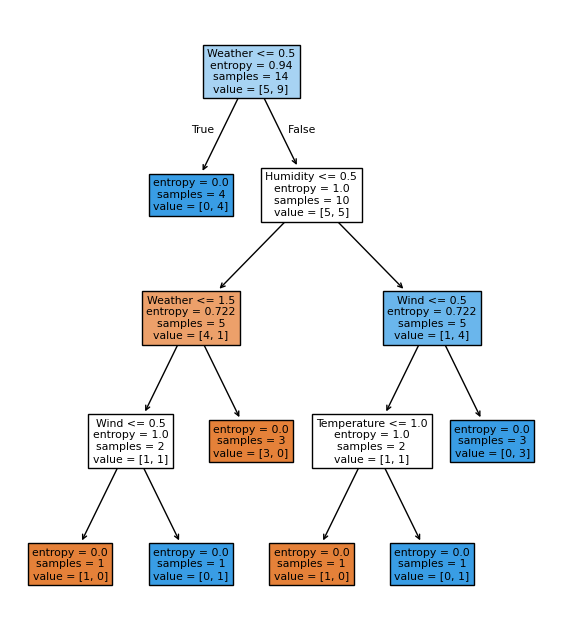

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(7,8))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

In [89]:
import pandas as pd

df = pd.read_csv("DecisionTree_Sports.csv")

df1=pd.get_dummies(data=df,columns=["Weather","Temperature","Humidity","Wind"])

In [90]:
df1.to_excel("DecisionTree_Sports_dummies.xlsx")  # to download excel file

In [91]:
x=df1.iloc[:,2:13]
y=df1["Play_Sports?"]
print(x)
print(x.shape)
print(y)
print(y.shape)

    Weather_Cloudy  Weather_Rain  Weather_Sunny  Temperature_Cool  \
0            False         False           True             False   
1            False         False           True             False   
2             True         False          False             False   
3            False          True          False             False   
4            False          True          False              True   
5            False          True          False              True   
6             True         False          False              True   
7            False         False           True             False   
8            False         False           True              True   
9            False          True          False             False   
10           False         False           True             False   
11            True         False          False             False   
12            True         False          False             False   
13           False          True  

In [92]:
from sklearn.tree import DecisionTreeClassifier

dtree= DecisionTreeClassifier(criterion="entropy")
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

['No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'No']


In [93]:
dtree.get_depth()

4

In [94]:
from sklearn import tree

text_representation=tree.export_text(dtree,feature_names=list(x.columns))
print(text_representation)

|--- Weather_Cloudy <= 0.50
|   |--- Humidity_Normal <= 0.50
|   |   |--- Weather_Sunny <= 0.50
|   |   |   |--- Wind_Weak <= 0.50
|   |   |   |   |--- class: No
|   |   |   |--- Wind_Weak >  0.50
|   |   |   |   |--- class: Yes
|   |   |--- Weather_Sunny >  0.50
|   |   |   |--- class: No
|   |--- Humidity_Normal >  0.50
|   |   |--- Wind_Weak <= 0.50
|   |   |   |--- Weather_Sunny <= 0.50
|   |   |   |   |--- class: No
|   |   |   |--- Weather_Sunny >  0.50
|   |   |   |   |--- class: Yes
|   |   |--- Wind_Weak >  0.50
|   |   |   |--- class: Yes
|--- Weather_Cloudy >  0.50
|   |--- class: Yes



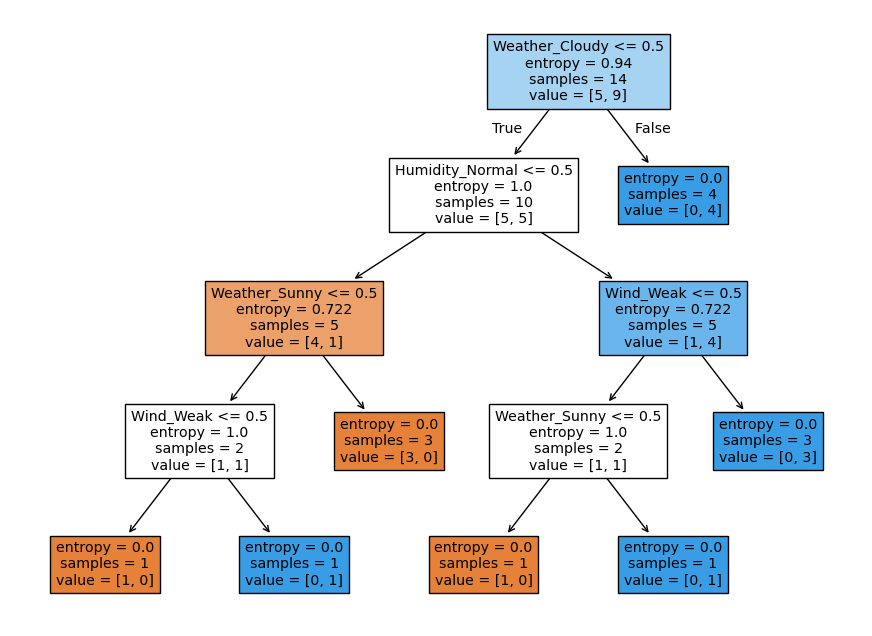

In [95]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(11,8))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

In [96]:
import pandas as pd

df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [97]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [98]:
df["Age"]=df["Age"].fillna(df["Age"].mean())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [99]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [100]:
x=df[["Pclass","Sex","Age","SibSp","Parch","Fare"]]
y=df["Survived"]
print(x)
print(y)

     Pclass     Sex        Age  SibSp  Parch     Fare
0         3    male  22.000000      1      0   7.2500
1         1  female  38.000000      1      0  71.2833
2         3  female  26.000000      0      0   7.9250
3         1  female  35.000000      1      0  53.1000
4         3    male  35.000000      0      0   8.0500
..      ...     ...        ...    ...    ...      ...
886       2    male  27.000000      0      0  13.0000
887       1  female  19.000000      0      0  30.0000
888       3  female  29.699118      1      2  23.4500
889       1    male  26.000000      0      0  30.0000
890       3    male  32.000000      0      0   7.7500

[891 rows x 6 columns]
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


In [101]:
x["Sex"]=x["Sex"].map({"female":0,"male":1})

C:\Users\LJENG\AppData\Local\Temp\ipykernel_10808\487326961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Sex"]=x["Sex"].map({"female":0,"male":1})


In [102]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.000000,1,0,7.2500
1,1,0,38.000000,1,0,71.2833
2,3,0,26.000000,0,0,7.9250
3,1,0,35.000000,1,0,53.1000
4,3,1,35.000000,0,0,8.0500
...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000
887,1,0,19.000000,0,0,30.0000
888,3,0,29.699118,1,2,23.4500
889,1,1,26.000000,0,0,30.0000


In [138]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [139]:
from sklearn.tree import DecisionTreeClassifier

dtree= DecisionTreeClassifier(criterion="entropy")
model=dtree.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1
 0 1 0 0 0 1 0 1 0 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 1
 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [140]:
from sklearn.metrics import confusion_matrix,accuracy_score

print("Confusion Matrix :",confusion_matrix(y_test,y_pred))
print("Accuracy Score :",accuracy_score(y_test,y_pred))

Confusion Matrix : [[91 15]
 [28 45]]
Accuracy Score : 0.7597765363128491


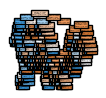

In [141]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(1,1))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

# Ramdon Forest

In [1]:
# ML algorithm that uses many decision trees to make better prediction
# Each tree looks at different random part of the data and their results arecombiened by voting for classifiction or avarageng for regression which makes if essemble learning techniqe helps in improving accures and redusing errors.

In [2]:
# Create many decision tree
# Pick random feature
# Each tree makes a prediction
# Combines the prediction

In [ ]:
# 1> Bagging (Bootstrap Aggregating)
#   it makes your dataset and creates random semples with replacement 
#   if you have 100 data
#   tree 1--> 1,5,20,50
#   tree 2--> 2,9,15,80

# Feature Randomness

In [3]:
import pandas as pd

df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df["Age"]=df["Age"].fillna(df["Age"].mean())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('titanic.csv')
df

df.isna().sum()

x = df[["Pclass",'Sex',"Age","SibSp","Parch","Fare"]]
y = df["Survived"]

import warnings
# warnings.filterwarnings('ignore') // for ignore warning
x['Sex']=x['Sex'].map({'male':1,'female':0})
x['Age']=x['Age'].fillna(x['Age'].median())
x

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.0,1,0,7.2500
1,1,0,38.0,1,0,71.2833
2,3,0,26.0,0,0,7.9250
3,1,0,35.0,1,0,53.1000
4,3,1,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000
887,1,0,19.0,0,0,30.0000
888,3,0,28.0,1,2,23.4500
889,1,1,26.0,0,0,30.0000


In [67]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [68]:
dtree.get_depth()
print("Depth of decision tree is: ",dtree.get_depth())

Depth of decision tree is:  20


In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier=RandomForestClassifier(n_estimators=100) # it gives random accuracy score every time
# rf_classifier=RandomForestClassifier(n_estimators=100,random_state=42) # it gives same accuracy score every time
rf_classifier.fit(x_train,y_train)
y_pred=rf_classifier.predict(x_test)
print(y_pred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [70]:
from sklearn.metrics import confusion_matrix,accuracy_score

print("Confusion Matrix :",confusion_matrix(y_test,y_pred))
print("Accuracy Score :",accuracy_score(y_test,y_pred))

Confusion Matrix : [[95 11]
 [29 44]]
Accuracy Score : 0.776536312849162


In [71]:
sample=x_test.iloc[0:1]
print(sample)
prediction=rf_classifier.predict(sample)
prediction

     Pclass  Sex   Age  SibSp  Parch     Fare
862       1    0  48.0      0      0  25.9292


array([1])

In [72]:
sample_dict=sample.iloc[0].to_dict()
print(sample_dict)
print(f"sample Passenger data : {sample_dict}")
print(f"predicted Survival : {'Survived' if prediction[0]==1 else 'Not Survived'}")

{'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
sample Passenger data : {'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
predicted Survival : Survived


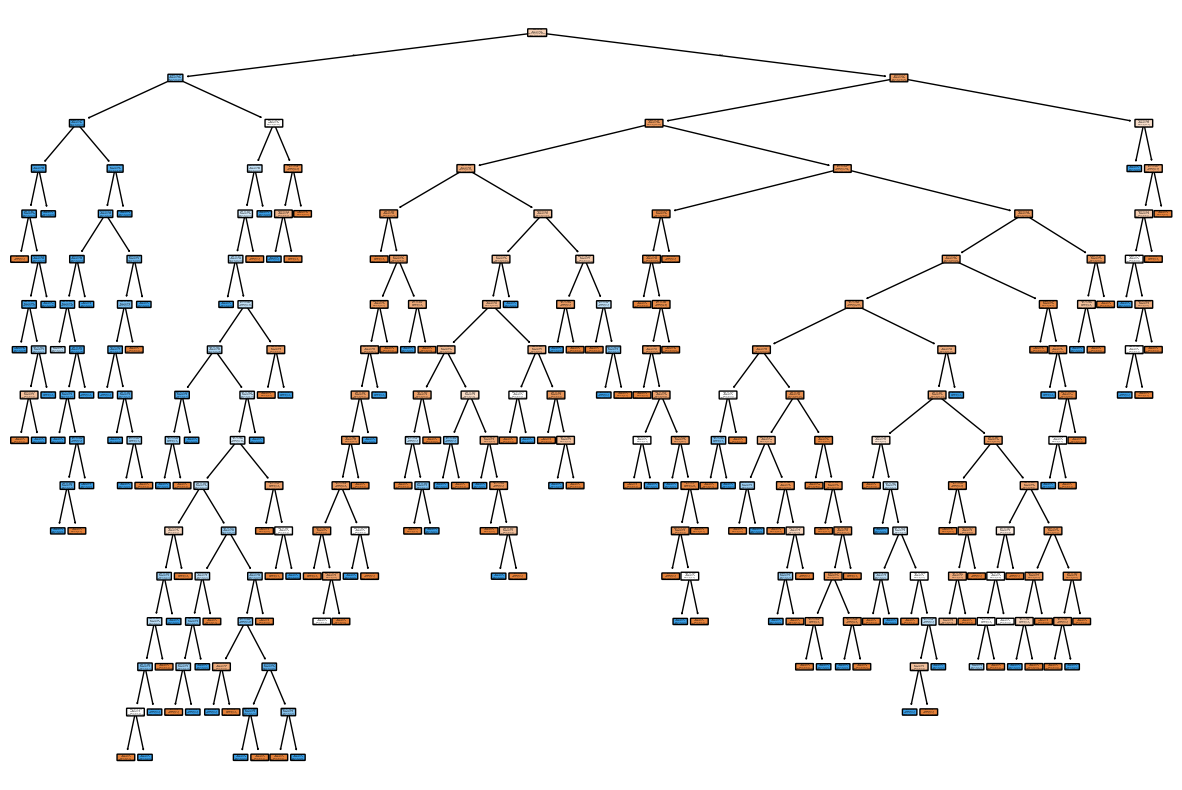

In [73]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
chosen_tree=rf_classifier.estimators_[0]
plt.figure(figsize=(15,10))
plot_tree(chosen_tree,feature_names=x.columns,class_names=['Not Survived','Survived'],filled=True,rounded=True)
plt.show()

In [82]:
import pandas as pd
data={"Weight":[150,170,140,180,160,155],
     "Texture":['smooth','Rough','smooth','Rough','smooth','Rough'],
     "Color":['Red','Orange','Green','Orange','Red','Yellow'],
     "Fruit":['Apple','orange','Apple','orange','Apple','orange']}
df=pd.DataFrame(data)
df

,Weight,Texture,Color,Fruit
0,150,smooth,Red,Apple
1,170,Rough,Orange,orange
2,140,smooth,Green,Apple
3,180,Rough,Orange,orange
4,160,smooth,Red,Apple
5,155,Rough,Yellow,orange


In [84]:
df = df.replace({
    'smooth': 0, 'Rough': 1,
    'Red': 0, 'Orange': 1, 'Green': 2, 'Yellow': 3
})

print(df)


   Weight  Texture  Color   Fruit
0     150        0      0   Apple
1     170        1      1  orange
2     140        0      2   Apple
3     180        1      1  orange
4     160        0      0   Apple
5     155        1      3  orange


In [89]:
x = df[["Weight",'Texture',"Color"]]
y = df["Fruit"]

In [90]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier=RandomForestClassifier(n_estimators=10,random_state=42,criterion='entropy') # it gives same accuracy score every time
rf_classifier.fit(x,y)
y_pred=rf_classifier.predict(x)
print(y_pred)

['Apple' 'orange' 'Apple' 'orange' 'Apple' 'orange']


# Support Vector Machine

In [ ]:
# --> SVN is famous for its ability to handle complex classification tasks.
# --> SVM looks for the optimal hyperplane that best separates different classes in a dataset.

In [91]:
# Decision Boundary --> line that separates the classes.
# Margin --> distance between the line and the nearest points of each class.
# Support Vectors --> data points that sit right on the edge of the decision boundaris.
#                 --> These are most important points because if you move them the boundary moves.

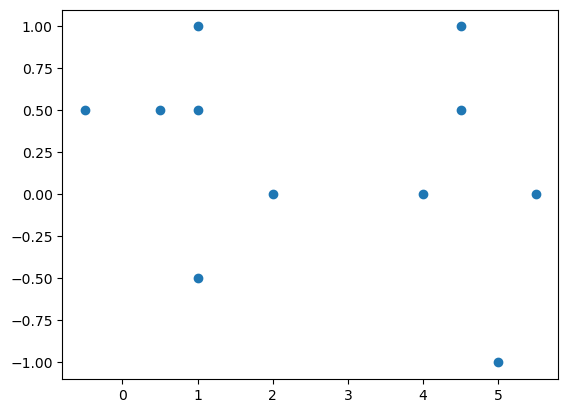

In [92]:
import matplotlib.pyplot as plt
x=[1,1,1,-0.5,0.5,2,4,4.5,4.5,5,5.5]
y=[0.5,1,-0.5,0.5,0.5,0,0,1,0.5,-1,0]

plt.scatter(x,y)
plt.show()

In [106]:
import pandas as pd

df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [107]:
x=df.iloc[:,:8]
y=df["Outcome"]
print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [108]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [110]:
from sklearn.svm import SVC
classifier=SVC(kernel="rbf",C=1.0,random_state=1)
classifier.fit(x_train,y_train)
prediction=classifier.predict(x_test)
print(prediction)

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]
